# Transaction Category Classifier
- Goal: classify transactions into categories using **MCC (Merchant Category Code) labels**.
- Steps: load data, map MCC codes to their official category descriptions, clean features, and train a classifier.
- Tweakable pieces: adjust `N_ROWS` for faster experiments, group MCC categories into higher-level categories if needed.

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Display options for quicker EDA
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

DATA_PATH = Path(r"c:/Users/naor0/OneDrive - Technion/Technion/Semester I/mockup/model/credit_card_transactions-ibm_v2.csv")
MCC_PATH = Path(r"c:/Users/naor0/OneDrive - Technion/Technion/Semester I/mockup/model/mcc_codes.json")

N_ROWS = 150_000  # set to None to load full dataset
RANDOM_STATE = 42

In [2]:
# Load data
raw = pd.read_csv(DATA_PATH, nrows=N_ROWS)
raw.columns = [
    col.lower().replace(" ", "_").replace("?", "").replace("/", "_")
    for col in raw.columns
]
print(f"Loaded shape: {raw.shape}")
raw.head()

Loaded shape: (150000, 15)


,user,card,year,month,day,time,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,errors,is_fraud
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


In [3]:
# Quick structure and basic stats
print("Columns:", list(raw.columns))
display(raw.describe(include='all').transpose().head(15))

Columns: ['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip', 'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'is_fraud']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user,150000.0,NaN,NaN,NaN,3.196453,2.037546,0.0,2.0,3.0,5.0,8.0
card,150000.0,NaN,NaN,NaN,1.14454,1.241211,0.0,0.0,1.0,2.0,4.0
year,150000.0,NaN,NaN,NaN,2011.475907,5.055825,1999.0,2007.0,2012.0,2016.0,2020.0
month,150000.0,NaN,NaN,NaN,6.517787,3.467226,1.0,3.0,7.0,10.0,12.0
day,150000.0,NaN,NaN,NaN,15.71814,8.80661,1.0,8.0,16.0,23.0,31.0
time,150000,1427,09:57,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,150000,21478,$60.00,4301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
use_chip,150000,3,Swipe Transaction,89334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_name,150000.0,NaN,NaN,NaN,-1027076018431510016.0,5186295170420311040.0,-9209171542573924352.0,-6035332392926028800.0,-2472481739355111424.0,4241336128694185472.0,9211695765166527488.0
merchant_city,150000,1574,ONLINE,31785,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clean fields and engineer simple features
df = raw.copy()
df['mcc'] = pd.to_numeric(df['mcc'], errors='coerce').astype('Int64')
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['time'] = pd.to_numeric(df['time'], errors='coerce')
df['hour'] = ((df['time'] // 100) % 24).astype('Int64')
df['use_chip'] = df['use_chip'].fillna('unknown').astype(str).str.lower()
if 'errors' in df.columns:
    df['errors'] = df['errors'].fillna('none').astype(str).str.lower()
for col in ['merchant_name', 'merchant_city', 'merchant_state']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str).str.lower()
df = df.drop_duplicates().reset_index(drop=True)
missing = df.isna().mean().sort_values(ascending=False)
print('Missingness (top 10):', missing.head(10))
df[['amount', 'month', 'day', 'hour']].describe().T

Missingness (top 10): amount      1.000000
time        1.000000
hour        1.000000
zip         0.203249
month       0.000000
year        0.000000
user        0.000000
card        0.000000
use_chip    0.000000
day         0.000000
dtype: float64


,count,mean,std,min,25%,50%,75%,max
amount,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,133137.0,6.521726,3.470054,1.0,3.0,7.0,10.0,12.0
day,133137.0,15.712755,8.80131,1.0,8.0,16.0,23.0,31.0
hour,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Load MCC category labels
- Load the MCC codes JSON file to map each transaction to its official category.
- Explore category distribution and identify any missing mappings.

In [5]:
# Load MCC category mapping
with open(MCC_PATH, 'r') as f:
    mcc_codes = json.load(f)

# Create a dictionary for quick MCC lookup
mcc_dict = {str(item['mcc']).zfill(4): item['edited_description'] for item in mcc_codes}

print(f"Loaded {len(mcc_dict)} MCC category definitions")

# Map MCC codes to categories
df['mcc_str'] = df['mcc'].astype(str).str.zfill(4)
df['category'] = df['mcc_str'].map(mcc_dict)

# Check coverage
total = len(df)
with_category = df['category'].notna().sum()
print(f"\nCategory coverage: {with_category}/{total} ({with_category/total*100:.1f}%)")

# Show category distribution (top 20)
print("\nTop 20 categories:")
print(df['category'].value_counts().head(20))

# Show some unmapped MCCs if any
unmapped = df[df['category'].isna()]['mcc'].value_counts().head(10)
if len(unmapped) > 0:
    print(f"\nTop unmapped MCCs:")
    print(unmapped)

Loaded 981 MCC category definitions

Category coverage: 133137/133137 (100.0%)

Top 20 categories:
category
Grocery Stores, Supermarkets                                                                           15277
Taxicabs and Limousines                                                                                11956
Toll and Bridge Fees                                                                                   11369
Drug Stores and Pharmacies                                                                             10849
Misc. Food Stores ג€“ Convenience Stores and Specialty Markets                                         10751
Money Orders ג€“ Wire Transfer                                                                          8568
Wholesale Clubs                                                                                         6549
Service Stations ( with or without ancillary services)                                                  5666
Eating places and Re

In [ ]:
# Group similar categories into higher-level buckets (optional)
# For 981 unique categories, we may want to create broader groups

# Load category groups from shared source of truth
CATEGORIES_PATH = Path(r"c:/Users/naor0/OneDrive - Technion/Technion/Semester I/mockup/backend/app/ml_models/categories.json")
with open(CATEGORIES_PATH, 'r') as f:
    CATEGORY_GROUPS = json.load(f)

print(f"Loaded {len(CATEGORY_GROUPS)} category groups from shared config")

def assign_group(category):
    if pd.isna(category):
        return 'Other'
    category_lower = str(category).lower()
    for group, keywords in CATEGORY_GROUPS.items():
        if any(keyword in category_lower for keyword in keywords):
            return group
    return 'Other'

df['category_group'] = df['category'].apply(assign_group)

print("Category group distribution:")
print(df['category_group'].value_counts())
print(f"\nUnique detailed categories: {df['category'].nunique()}")
print(f"Grouped into: {df['category_group'].nunique()} high-level categories")

Category group distribution:
category_group
Shopping                 32384
Transportation           25293
Food & Dining            23845
Other                    21644
Groceries                15277
Fuel                      8886
Entertainment             2514
Telecom                   2468
Healthcare                 432
Home & Garden              219
Professional Services      175
Name: count, dtype: int64

Unique detailed categories: 103
Grouped into: 11 high-level categories


In [7]:
df.columns

Index(['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip', 'merchant_name', 'merchant_city',
       'merchant_state', 'zip', 'mcc', 'errors', 'is_fraud', 'hour', 'mcc_str', 'category', 'category_group'],
      dtype='object')

In [8]:
# Prepare data for classification
# Filter to only transactions with valid categories
model_df = df[df['category_group'].notna() & df['category_group'].ne('Other')].copy()

print(f"Training data: {len(model_df)} transactions with valid categories")
print(f"\nClass distribution:")
print(model_df['category_group'].value_counts())

# Select features and target
feature_cols = ['amount', 'month', 'day', 'hour', 'merchant_name', 'merchant_city', 'merchant_state', 'use_chip']
X = model_df[feature_cols]
y = model_df['category_group']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Training data: 111493 transactions with valid categories

Class distribution:
category_group
Shopping                 32384
Transportation           25293
Food & Dining            23845
Groceries                15277
Fuel                      8886
Entertainment             2514
Telecom                   2468
Healthcare                 432
Home & Garden              219
Professional Services      175
Name: count, dtype: int64

Train size: 89194, Test size: 22299


In [9]:
# Build classification pipeline
numeric_features = ['amount', 'month', 'day', 'hour']
categorical_features = ['merchant_city', 'merchant_state', 'use_chip']
text_feature = 'merchant_name'

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=100), categorical_features),
    ('text', TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=5), text_feature)
], remainder='drop')

# Try Random Forest classifier
clf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1))
])

print("Training Random Forest classifier...")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training Random Forest classifier...


c:\Users\naor0\OneDrive - Technion\Technion\Semester I\mockup\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['amount' 'hour']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\naor0\OneDrive - Technion\Technion\Semester I\mockup\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['amount' 'hour']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Accuracy: 0.902

Classification Report:
                       precision    recall  f1-score   support

        Entertainment       1.00      0.72      0.84       503
        Food & Dining       1.00      0.80      0.89      4769
                 Fuel       1.00      0.83      0.91      1777
            Groceries       1.00      0.91      0.95      3055
           Healthcare       0.00      0.00      0.00        86
        Home & Garden       1.00      0.18      0.31        44
Professional Services       0.00      0.00      0.00        35
             Shopping       0.75      1.00      0.86      6477
              Telecom       1.00      0.80      0.89       494
       Transportation       0.99      0.95      0.97      5059

             accuracy                           0.90     22299
            macro avg       0.77      0.62      0.66     22299
         weighted avg       0.92      0.90      0.90     22299



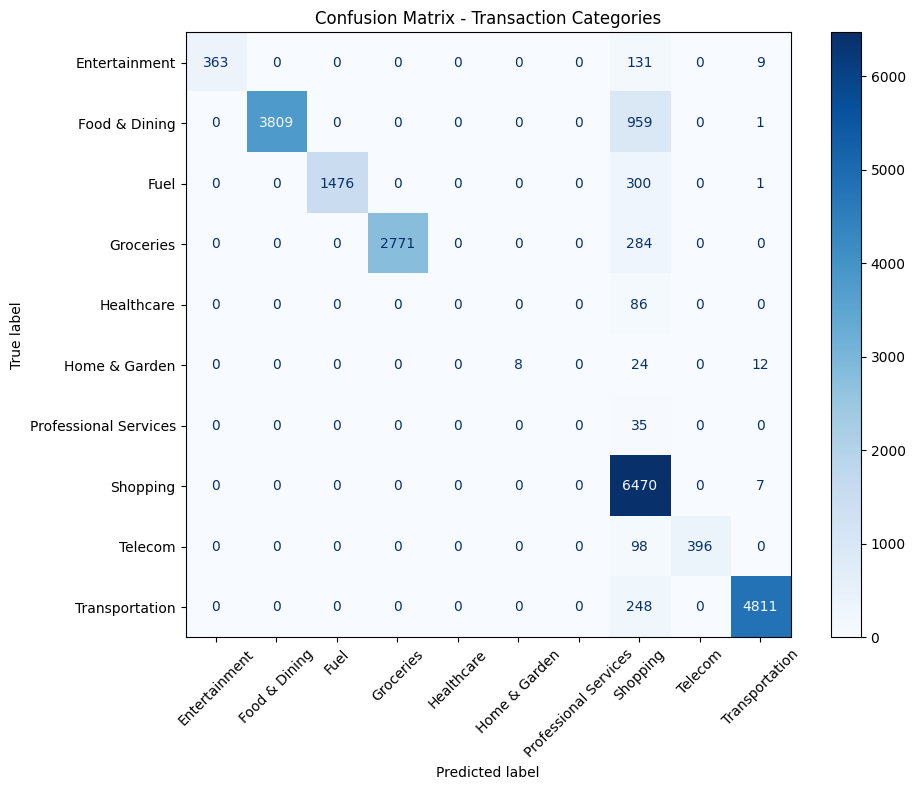

In [10]:
# Confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    ax=ax, 
    cmap='Blues',
    xticks_rotation=45
)
plt.title('Confusion Matrix - Transaction Categories')
plt.tight_layout()
plt.show()

## Sample predictions
Let's test the model on some sample transactions to see how it categorizes them.

In [11]:
# Show sample predictions
samples = X_test.head(15).copy()
samples['actual'] = y_test.head(15).values
samples['predicted'] = y_pred[:15]

print("Sample predictions:")
for idx, row in samples.iterrows():
    match = "✓" if row['actual'] == row['predicted'] else "✗"
    print(f"{match} {row['merchant_name'][:40]:40} | ${row['amount']:6.2f} | Actual: {row['actual']:20} | Predicted: {row['predicted']}")

Sample predictions:
✓ -3499623102051145071                     | $   nan | Actual: Shopping             | Predicted: Shopping
✓ 6455213054093379528                      | $   nan | Actual: Entertainment        | Predicted: Entertainment
✓ 9057735476014445185                      | $   nan | Actual: Shopping             | Predicted: Shopping
✓ -6094718405726678882                     | $   nan | Actual: Fuel                 | Predicted: Fuel
✓ 2027553650310142703                      | $   nan | Actual: Fuel                 | Predicted: Fuel
✓ -6458444334611773637                     | $   nan | Actual: Transportation       | Predicted: Transportation
✓ -6831460391606994695                     | $   nan | Actual: Fuel                 | Predicted: Fuel
✓ -6458444334611773637                     | $   nan | Actual: Transportation       | Predicted: Transportation
✓ -5841929396161652653                     | $   nan | Actual: Transportation       | Predicted: Transportation
✗ 5427095414889

## Next steps
1. **Refine category groups**: Adjust `CATEGORY_GROUPS` keywords in cell 8 to improve grouping accuracy.
2. **Try other models**: Test Logistic Regression, XGBoost, or Neural Networks for comparison.
3. **Feature engineering**: Add day-of-week, weekend flags, merchant clustering, or rolling averages.
4. **Handle detailed categories**: Instead of grouping, try classifying into the full 981 MCC categories (may need more data/features).
5. **Save model**: Export the trained pipeline using `joblib` for production use.
6. **MCC lookup fallback**: For new transactions, if the model fails, fall back to direct MCC→category lookup from the JSON.

## Save model artifacts for production

In [12]:
import joblib
from datetime import datetime

# Create output directory if it doesn't exist
output_dir = Path("../backend/app/ml_models")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the trained pipeline
model_path = output_dir / "transaction_classifier.pkl"
joblib.dump(clf, model_path)
print(f"✓ Saved trained model to: {model_path}")

# Save MCC dictionary for fallback lookups
mcc_dict_path = output_dir / "mcc_categories.pkl"
joblib.dump(mcc_dict, mcc_dict_path)
print(f"✓ Saved MCC dictionary to: {mcc_dict_path}")

# Save category groups mapping
category_groups_path = output_dir / "category_groups.pkl"
joblib.dump(CATEGORY_GROUPS, category_groups_path)
print(f"✓ Saved category groups to: {category_groups_path}")

# Save model metadata
metadata = {
    "model_type": "RandomForestClassifier",
    "n_estimators": 100,
    "max_depth": 20,
    "accuracy": float(accuracy),
    "n_classes": len(clf.classes_),
    "classes": list(clf.classes_),
    "training_date": datetime.now().isoformat(),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
    "features": feature_cols,
    "n_rows_used": N_ROWS
}

metadata_path = output_dir / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata to: {metadata_path}")

print(f"\nModel artifacts ready for integration!")
print(f"Classes: {', '.join(clf.classes_)}")

✓ Saved trained model to: ..\backend\app\ml_models\transaction_classifier.pkl
✓ Saved MCC dictionary to: ..\backend\app\ml_models\mcc_categories.pkl
✓ Saved category groups to: ..\backend\app\ml_models\category_groups.pkl
✓ Saved metadata to: ..\backend\app\ml_models\model_metadata.json

Model artifacts ready for integration!
Classes: Entertainment, Food & Dining, Fuel, Groceries, Healthcare, Home & Garden, Professional Services, Shopping, Telecom, Transportation


## How to use the saved model in your app

```python
import joblib
from pathlib import Path

# Load the model
model = joblib.load('backend/app/ml_models/transaction_classifier.pkl')
mcc_dict = joblib.load('backend/app/ml_models/mcc_categories.pkl')

# Predict category for a new transaction
transaction = {
    'amount': 45.99,
    'month': 1,
    'day': 15,
    'hour': 14,
    'merchant_name': 'whole foods market',
    'merchant_city': 'san francisco',
    'merchant_state': 'ca',
    'use_chip': 'swipe'
}

import pandas as pd
X_new = pd.DataFrame([transaction])
predicted_category = model.predict(X_new)[0]
print(f"Predicted: {predicted_category}")

# Fallback: if MCC is known, use direct lookup
mcc_code = '5411'
if mcc_code in mcc_dict:
    category = mcc_dict[mcc_code]
    print(f"MCC lookup: {category}")
```